=======================================================================
# California Housing Regression Notebook
=======================================================================

INTRODUCTION
------------
The California Housing dataset is a well-known dataset often used to
illustrate regression techniques. It contains various features about
different neighborhoods in California, such as:
- latitude, longitude
- housing_median_age
- total_rooms, total_bedrooms
- population
- households
- median_income

The target variable is "median_house_value," which represents
the median house value (in hundreds of thousands of dollars) for
that particular neighborhood.

In this notebook, we will:
1. Load data from the CSV files provided in Google Colab
   ("california_housing_train.csv" and "california_housing_test.csv").
2. Explore the data and discuss key concepts such as features and target.
3. Preprocess the data for modeling.
4. Compare several regression models:
   - Simple Linear Regression (using one feature).
   - Multiple Linear Regression (using all features).
   - Polynomial Regression.
   - Support Vector Regression (SVR).
   - Decision Tree Regression.
   - Random Forest Regression.
5. Evaluate each model’s performance using:
   - Mean Squared Error (MSE).
   - R-squared (R^2).

KEY VOCABULARY
--------------
- **Regression**: A predictive modeling technique used to estimate or predict
  a continuous numerical value.  
- **Features (X)**: Independent variables or predictors used by the model to
  estimate the target. In our dataset, these include numerical data such as
  "median_income" or "total_rooms."
- **Target (y)**: The dependent variable or the outcome we aim to predict.
  Here, it is "median_house_value."
- **Mean Squared Error (MSE)**: The average of the squared differences between
  the predicted and actual values. A lower MSE indicates better performance.
- **R-squared (R^2)**: A measure of how much of the target’s variance is
  explained by the model. An R^2 closer to 1 indicates a better fit.
- **Overfitting**: When a model performs extremely well on training data but
  poorly on new, unseen data.
- **Underfitting**: When a model is too simple and fails to capture the
  underlying relationship in the data.

By the end of this notebook, you will have a clear understanding of how
different regression models perform on the California Housing dataset,
including potential strengths and weaknesses. Let's get started!
"""


## 1. Data Loading and Preprocessing

We load the `california_housing_test.csv` file from the `sample_data` folder. Then we inspect the data and perform basic preprocessing.


In [1]:
# =========================
# 1. IMPORTS & SETUP
# =========================
# 1. Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For statsmodels OLS
import statsmodels.api as sm

# For scikit-learn regression models and preprocessing
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

In [2]:
# =========================
# 2. LOADING THE CSV DATA
# =========================
"""
In Google Colab, these files typically reside in 'sample_data/'.
We'll load them directly as train and test sets.
"""

train_df = pd.read_csv('sample_data/california_housing_train.csv')
test_df = pd.read_csv('sample_data/california_housing_test.csv')

print("Train data shape:", train_df.shape)
print("Test data shape:", test_df.shape)

# Display a preview of the training set
train_df.head()


Train data shape: (17000, 9)
Test data shape: (3000, 9)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0



=== Training Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB

=== Descriptive Statistics (Train) ===


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000



=== Checking for Missing Values (Train) ===
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64


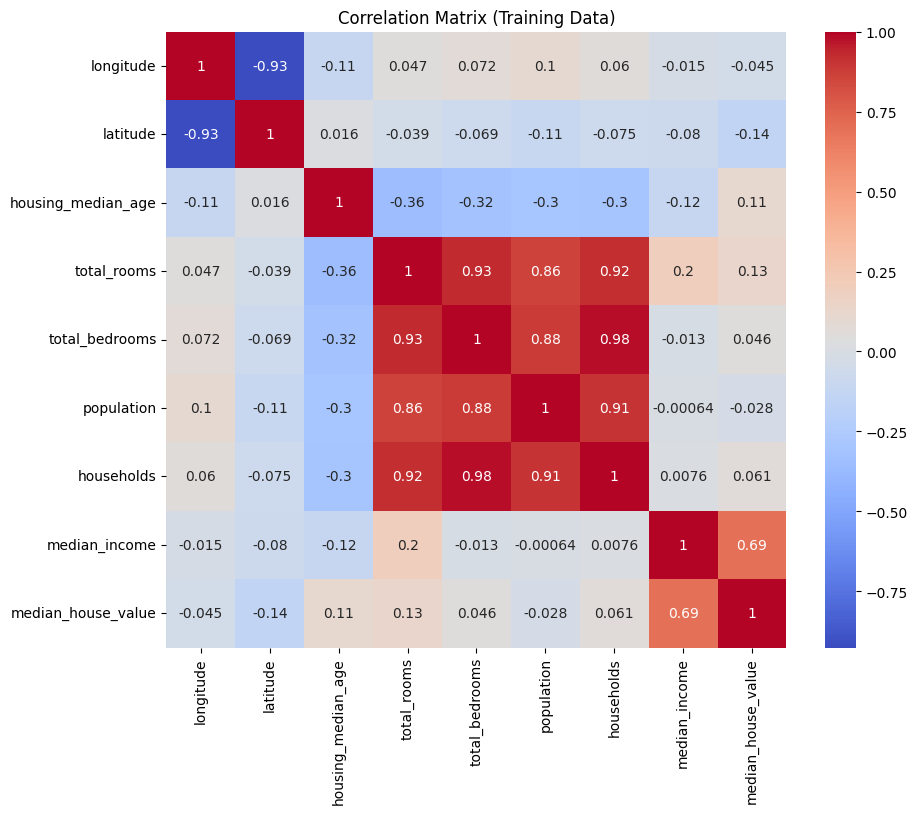

In [3]:
# =========================
# 3. EXPLORATORY DATA ANALYSIS
# =========================
print("\n=== Training Data Info ===")
train_df.info()

print("\n=== Descriptive Statistics (Train) ===")
display(train_df.describe())

print("\n=== Checking for Missing Values (Train) ===")
print(train_df.isnull().sum())

# Correlation heatmap (train set)
plt.figure(figsize=(10, 8))
sns.heatmap(train_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix (Training Data)")
plt.show()

In [4]:
# Get the features in X and Target in y
X_train = train_df.iloc[:,7].values.reshape(-1, 1) # Reshape X_train to 2D
y_train = train_df.iloc[:, -1].values

In [5]:
# Get the features in X and Target in y
X_test = test_df.iloc[:,7].values.reshape(-1, 1) # Reshape X_train to 2D
y_test = test_df.iloc[:, -1].values

In [6]:
X_train

array([[1.4936],
       [1.82  ],
       [1.6509],
       ...,
       [3.0313],
       [1.9797],
       [3.0147]])

In [7]:
y_train

array([ 66900.,  80100.,  85700., ..., 103600.,  85800.,  94600.])

In [8]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
# Fitting Simple Linear Regression to the Training set
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [10]:
# Predicting the Test set results
y_pred = regressor.predict(X_test)

In [11]:
import statsmodels.api as sm

# Getting the coefficients and intercept
coefficients = regressor.coef_
intercept = regressor.intercept_

# Calculate p-value using statsmodels
# Adding a constant to X_train for the intercept
X_train_with_constant = sm.add_constant(X_train)

# Fit the statsmodels OLS model to calculate p-values
model = sm.OLS(y_train, X_train_with_constant)
results = model.fit()

# Display the statistical summary
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.479
Model:                            OLS   Adj. R-squared:                  0.479
Method:                 Least Squares   F-statistic:                 1.561e+04
Date:                Wed, 29 Oct 2025   Prob (F-statistic):               0.00
Time:                        09:46:02   Log-Likelihood:            -2.1683e+05
No. Observations:               17000   AIC:                         4.337e+05
Df Residuals:                   16998   BIC:                         4.337e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.073e+05    642.297    322.749      0.0

In [12]:
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 7009935982.673599


let us try Multiple Lineaer Regression

In [13]:
# prompt: let us try Multiple Lineaer Regression

# Multiple Linear Regression

# Prepare the data
X_train_multiple = train_df.drop('median_house_value', axis=1)
y_train_multiple = train_df['median_house_value']

X_test_multiple = test_df.drop('median_house_value', axis=1)
y_test_multiple = test_df['median_house_value']

scaler_multiple = StandardScaler()
X_train_multiple = scaler_multiple.fit_transform(X_train_multiple)
X_test_multiple = scaler_multiple.transform(X_test_multiple)

# Multiple Linear Regression
regressor_multiple = LinearRegression()
regressor_multiple.fit(X_train_multiple, y_train_multiple)

LinearRegression()

In [14]:
# Predicting the Test set results
y_pred_multiple = regressor_multiple.predict(X_test_multiple)

In [15]:
y_pred_multiple

array([352812.31112454, 212717.70074517, 272344.69951889, ...,
        88220.58643731, 146374.67481455, 456779.61107786])

In [16]:
# Evaluate the model
mse_multiple = mean_squared_error(y_test_multiple, y_pred_multiple)
r2_multiple = r2_score(y_test_multiple, y_pred_multiple)
#adjusted_r_squared = results_multiple.rsquared_adj

print(f"Multiple Linear Regression - Mean Squared Error: {mse_multiple}")
print(f"Multiple Linear Regression - R-squared: {r2_multiple}")
#print(f"Multiple Linear Regression - Adjusted R-squared: {adjusted_r_squared}")

Multiple Linear Regression - Mean Squared Error: 4867205486.928867
Multiple Linear Regression - R-squared: 0.6195057678311999


In [17]:
# Calculate p-values using statsmodels (for multiple regression)
X_train_multiple_with_constant = sm.add_constant(X_train_multiple)
model_multiple = sm.OLS(y_train_multiple, X_train_multiple_with_constant)
results_multiple = model_multiple.fit()
print(results_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:     median_house_value   R-squared:                       0.641
Model:                            OLS   Adj. R-squared:                  0.641
Method:                 Least Squares   F-statistic:                     3798.
Date:                Wed, 29 Oct 2025   Prob (F-statistic):               0.00
Time:                        09:46:02   Log-Likelihood:            -2.1365e+05
No. Observations:               17000   AIC:                         4.273e+05
Df Residuals:                   16991   BIC:                         4.274e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.073e+05    532.866    389.030      0.0

In [18]:
# Polynomial Linear Regression
poly_reg = PolynomialFeatures(degree=2)  # You can adjust the degree
X_poly_train = poly_reg.fit_transform(X_train)
X_poly_test = poly_reg.transform(X_test)

poly_regressor = LinearRegression()
poly_regressor.fit(X_poly_train, y_train)

LinearRegression()

In [19]:
# Predicting the Test set results
y_poly_pred = poly_regressor.predict(X_poly_test)

# Evaluate the model
mse_poly = mean_squared_error(y_test, y_poly_pred)
r2_poly = r2_score(y_test, y_poly_pred)

print(f"Polynomial Regression - Mean Squared Error: {mse_poly}")
print(f"Polynomial Regression - R-squared: {r2_poly}")

Polynomial Regression - Mean Squared Error: 6961452119.629252
Polynomial Regression - R-squared: 0.4557878466089694


In [20]:
# Fit SVR to the Training set
svr_regressor = SVR(kernel='rbf') # You can experiment with different kernels ('linear', 'poly', etc.)
svr_regressor.fit(X_train_multiple, y_train_multiple)

# Predicting the Test set results
y_svr_pred = svr_regressor.predict(X_test_multiple)

# Evaluate the model
mse_svr = mean_squared_error(y_test_multiple, y_svr_pred)
r2_svr = r2_score(y_test_multiple, y_svr_pred)

print(f"Support Vector Regression - Mean Squared Error: {mse_svr}")
print(f"Support Vector Regression - R-squared: {r2_svr}")


Support Vector Regression - Mean Squared Error: 13364065828.279503
Support Vector Regression - R-squared: -0.044737063113609254


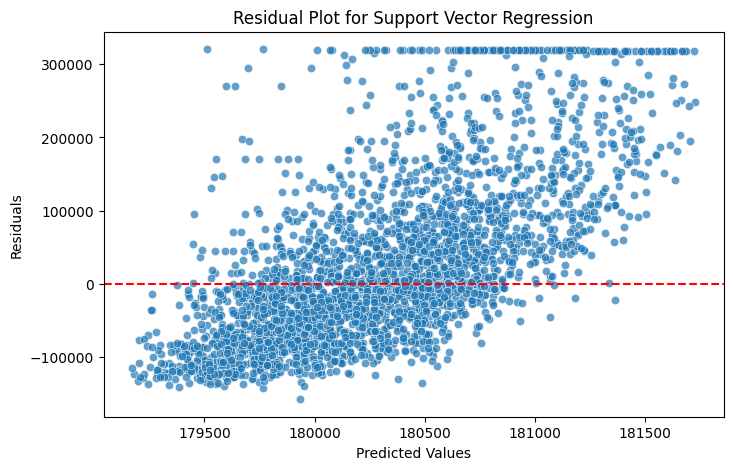

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
residuals = y_test_multiple - y_svr_pred

# Create the residual plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_svr_pred, y=residuals, alpha=0.7)

# Add a horizontal reference line at 0
plt.axhline(y=0, color='r', linestyle='--')

# Labels and title
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot for Support Vector Regression")
plt.show()

In [22]:
# Decision Tree Regression
tree_regressor = DecisionTreeRegressor(random_state=0) # You can tune hyperparameters like max_depth, min_samples_split, etc.
tree_regressor.fit(X_train_multiple, y_train_multiple)

# Predicting the Test set results
y_tree_pred = tree_regressor.predict(X_test_multiple)

# Evaluate the model
mse_tree = mean_squared_error(y_test_multiple, y_tree_pred)
r2_tree = r2_score(y_test_multiple, y_tree_pred)

print(f"Decision Tree Regression - Mean Squared Error: {mse_tree}")
print(f"Decision Tree Regression - R-squared: {r2_tree}")


Decision Tree Regression - Mean Squared Error: 4598624236.974
Decision Tree Regression - R-squared: 0.6405021315045563


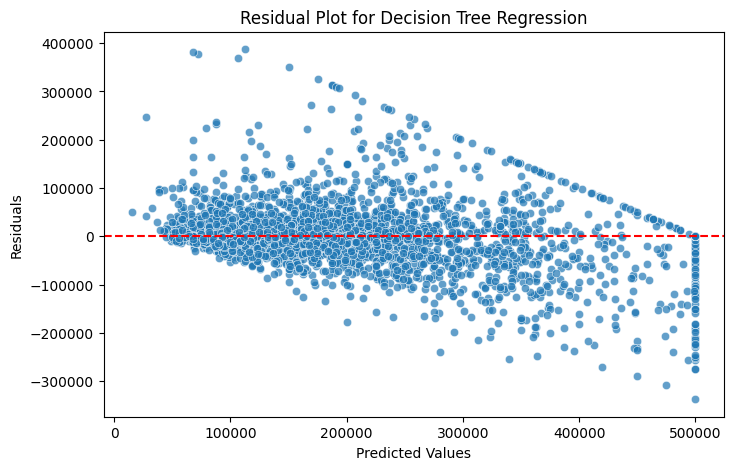

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
residuals = y_test_multiple - y_tree_pred

# Create the residual plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_tree_pred, y=residuals, alpha=0.7)

# Add a horizontal reference line at 0
plt.axhline(y=0, color='r', linestyle='--')

# Labels and title
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot for Decision Tree Regression")
plt.show()


In [24]:
# Random Forest Regression
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=0)  # 100 trees
rf_regressor.fit(X_train_multiple, y_train_multiple)

# Predicting the Test set results
y_rf_pred = rf_regressor.predict(X_test_multiple)

# Evaluate the model
mse_rf = mean_squared_error(y_test_multiple, y_rf_pred)
r2_rf = r2_score(y_test_multiple, y_rf_pred)

print(f"Random Forest Regression - Mean Squared Error: {mse_rf}")
print(f"Random Forest Regression - R-squared: {r2_rf}")


Random Forest Regression - Mean Squared Error: 2423424214.9645514
Random Forest Regression - R-squared: 0.8105485913079777


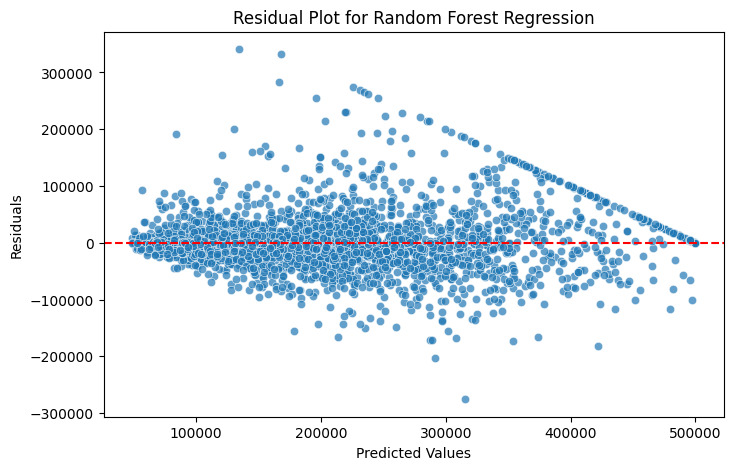

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
residuals = y_test_multiple - y_rf_pred

# Create the plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_rf_pred, y=residuals, alpha=0.7)

# Add a reference line at 0
plt.axhline(y=0, color='r', linestyle='--')

# Labels and title
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot for Random Forest Regression")
plt.show()


In [26]:

import pandas as pd

data = {
    'Model': ['Simple Linear Regression', 'Multiple Linear Regression', 'Polynomial Regression', 'Support Vector Regression', 'Decision Tree Regression', 'Random Forest Regression'],
    'MSE': [mse, mse_multiple, mse_poly, mse_svr, mse_tree, mse_rf],
    'R-squared': [r2_score(y_test, y_pred), r2_multiple, r2_poly, r2_svr, r2_tree, r2_rf]
}

df = pd.DataFrame(data)
df


,Model,MSE,R-squared
0,Simple Linear Regression,7.009936e+09,0.451998
1,Multiple Linear Regression,4.867205e+09,0.619506
2,Polynomial Regression,6.961452e+09,0.455788
3,Support Vector Regression,1.336407e+10,-0.044737
4,Decision Tree Regression,4.598624e+09,0.640502
5,Random Forest Regression,2.423424e+09,0.810549


In [27]:
# prompt: apply lasso and let us train again

import pandas as pd
from sklearn.linear_model import Lasso


# Initialize and train the Lasso model
lasso_regressor = Lasso(alpha=0.1)  # You can adjust the alpha parameter
lasso_regressor.fit(X_train_multiple, y_train_multiple)

# Predicting the Test set results
y_lasso_pred = lasso_regressor.predict(X_test_multiple)

# Evaluate the model
mse_lasso = mean_squared_error(y_test_multiple, y_lasso_pred)
r2_lasso = r2_score(y_test_multiple, y_lasso_pred)

print(f"Lasso Regression - Mean Squared Error: {mse_lasso}")
print(f"Lasso Regression - R-squared: {r2_lasso}")




Lasso Regression - Mean Squared Error: 4867203682.9396
Lasso Regression - R-squared: 0.6195059088582251


In [28]:

import pandas as pd

data = {
    'Model': ['Simple Linear Regression', 'Multiple Linear Regression', 'Polynomial Regression', 'Support Vector Regression', 'Decision Tree Regression', 'Random Forest Regression' , "lasson"],
    'MSE': [mse, mse_multiple, mse_poly, mse_svr, mse_tree, mse_rf, mse_lasso],
    'R-squared': [r2_score(y_test, y_pred), r2_multiple, r2_poly, r2_svr, r2_tree, r2_rf, r2_lasso]
}

df = pd.DataFrame(data)
df


,Model,MSE,R-squared
0,Simple Linear Regression,7.009936e+09,0.451998
1,Multiple Linear Regression,4.867205e+09,0.619506
2,Polynomial Regression,6.961452e+09,0.455788
3,Support Vector Regression,1.336407e+10,-0.044737
4,Decision Tree Regression,4.598624e+09,0.640502
5,Random Forest Regression,2.423424e+09,0.810549
6,lasson,4.867204e+09,0.619506


# Random Forest

In [29]:
train_df = pd.read_csv('sample_data/california_housing_train.csv')
test_df = pd.read_csv('sample_data/california_housing_test.csv')

# Prepare the data
X_train_multiple = train_df.drop('median_house_value', axis=1)
y_train_multiple = train_df['median_house_value']

X_test_multiple = test_df.drop('median_house_value', axis=1)
y_test_multiple = test_df['median_house_value']

# Random Forest Regression
rf_regressor = RandomForestRegressor(n_estimators=50, random_state=0)
rf_regressor.fit(X_train_multiple, y_train_multiple)

# Predicting the Test set results
y_rf_pred = rf_regressor.predict(X_test_multiple)

# Evaluate the model
mse_rf = mean_squared_error(y_test_multiple, y_rf_pred)
r2_rf = r2_score(y_test_multiple, y_rf_pred)

print(f"Random Forest Regression - Mean Squared Error: {mse_rf}")
print(f"Random Forest Regression - R-squared: {r2_rf}")

Random Forest Regression - Mean Squared Error: 2439840301.2532
Random Forest Regression - R-squared: 0.809265262267445


In [31]:
# prompt: how do you suggest to improve the random forest model ?

# Hyperparameter Tuning:
# - n_estimators: Increase the number of trees (e.g., from 100 to 200 or more).  More trees generally lead to better performance, but also increase computation time.  Find the sweet spot.
# - max_dept: Control the depth of individual trees.  Too deep can lead to overfitting.  Experiment with different values.
# - min_samples_split: The minimum number of samples required to split an internal node.  Adjust this to prevent overfitting to small subsets of the data.
# - min_samples_leaf:  The minimum number of samples required to be at a leaf node. Similar to min_samples_split, helps prevent overfitting.
# - max_features: The number of features to consider when looking for the best split.  Values less than the total number of features can improve generalization.


from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Define the parameter grid for GridSearchCV or RandomizedSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Create a RandomForestRegressor object
rf_regressor = RandomForestRegressor(random_state=0)

# Initialize GridSearchCV or RandomizedSearchCV
# GridSearchCV will try every combination; RandomizedSearchCV will try a random sample
grid_search = GridSearchCV(estimator=rf_regressor, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error') # cv=5 for 5-fold cross-validation

# Fit the grid search to the data
grid_search.fit(X_train_multiple, y_train_multiple)

# Get the best hyperparameters
best_params = grid_search.best_params_
print(f"Best Hyperparameters: {best_params}")

# Train the model with the best hyperparameters
best_rf_regressor = RandomForestRegressor(**best_params, random_state=0)  # Use **best_params to unpack the dictionary
best_rf_regressor.fit(X_train_multiple, y_train_multiple)

# Make predictions
y_pred = best_rf_regressor.predict(X_test_multiple)

# Evaluate the model (with the best hyperparameters)
mse = mean_squared_error(y_test_multiple, y_pred)
r2 = r2_score(y_test_multiple, y_pred)

print(f"Random Forest with Best Hyperparameters - Mean Squared Error: {mse}")
print(f"Random Forest with Best Hyperparameters - R-squared: {r2}")

# Feature Importance
feature_importances = best_rf_regressor.feature_importances_

# Print feature importances with corresponding feature names
for feature_name, importance in zip(X_train_multiple.columns, feature_importances):
  print(f"{feature_name}: {importance}")

KeyboardInterrupt: 